In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [3]:
# =========================
# COMPUTATION CELL
# =========================
import os
import math
import random
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import umap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Paths ---
processed_path = '/home/lnemati/pathway_crosstalk/data/immunotherapy/tissues/'
dataset_path = '/home/lnemati/pathway_crosstalk/data/immunotherapy/full_dataset_with_clinical.csv'

# --- Load dataset ---
full_dataset_unprocessed = pd.read_csv(dataset_path, index_col=0)

clinical_cols = list(full_dataset_unprocessed.columns[:44]) + ['condition', 'type', 'gender', 'study']
metadata = full_dataset_unprocessed[clinical_cols].copy()
metadata['batch'] = metadata['batch'].replace({1: 'TIGER', 2: 'TCGA', 3: 'IMvigor210'})

gene_cols_unprocessed = [c for c in full_dataset_unprocessed.columns if c not in metadata.columns]

# --- Preprocessing ---
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

# --- Files ---
processed_files = [f for f in os.listdir(processed_path) if f.endswith('.csv')]

valid_files = []
for file in processed_files:
    df = pd.read_csv(
        os.path.join(processed_path, file),
        index_col=0,
        usecols=lambda c: c != 'response_NR'
    )

    common_index = df.index.intersection(full_dataset_unprocessed.index)
    tissue_batches = metadata.loc[common_index, 'batch'].unique()

    if len(tissue_batches) > 1:
        valid_files.append(file)

valid_files.sort(key=lambda x: (0 if x.lower() == 'full_dataset.csv' else 1, x.lower()))

# --- STORAGE ---
results = {}

for file in valid_files:

    full_dataset_processed = pd.read_csv(
        os.path.join(processed_path, file),
        index_col=0
    ).drop(columns='response_NR', errors='ignore')

    common_index = sorted(
        full_dataset_processed.index.intersection(full_dataset_unprocessed.index)
    )

    unprocessed_subset = full_dataset_unprocessed.loc[common_index, gene_cols_unprocessed]
    processed_subset   = full_dataset_processed.loc[common_index]

    # --- preprocess ---
    X_unprocessed = scaler.fit_transform(imputer.fit_transform(unprocessed_subset.values))
    X_processed   = scaler.fit_transform(imputer.fit_transform(processed_subset.values))

    # --- PCA ---
    n_pc = min(30, X_processed.shape[0])
    pca = PCA(n_components=n_pc, random_state=SEED)

    X_unprocessed_pc = pca.fit_transform(X_unprocessed)
    X_processed_pc   = pca.fit_transform(X_processed)

    # --- UMAP ---
    umap_model = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=SEED,
        n_jobs=1
    )

    umap_unprocessed = umap_model.fit_transform(X_unprocessed_pc)
    umap_processed   = umap_model.fit_transform(X_processed_pc)

    # --- store ---
    results[file] = {
        "unprocessed": pd.DataFrame(
            umap_unprocessed,
            columns=['UMAP1','UMAP2'],
            index=common_index
        ).join(metadata.loc[common_index]),

        "processed": pd.DataFrame(
            umap_processed,
            columns=['UMAP1','UMAP2'],
            index=common_index
        ).join(metadata.loc[common_index])
    }

print(f"Computed {len(results)} tissues")

/var/tmp/pbs.436024.pbs01/ipykernel_279098/2915594154.py:23: DtypeWarning: Columns (0: Treatment, 1: response, 2: response_NR, 3: overall survival (days), 4: Total Mutation, 5: therapy_type, 6: age_start, 7: seq_type, 8: id, 9: tissue, 10: Best Confirmed Overall Response, 11: binaryResponse, 12: Enrollment IC, 13: IC Level, 14: TC Level, 15: Immune phenotype, 16: FMOne mutation burden per MB, 17: Race, 18: Intravesical BCG administered, 19: Baseline ECOG Score, 20: Met Disease Status, 21: Sample age, 22: Tissue, 23: Received platinum, 24: Sample collected pre-platinum, 25: Neoantigen burden per MB, 26: Lund2, 27: TCGA Subtype, 28: batch, 29: type, 30: gender, 31: study, 32: OS) have mixed types. Specify dtype option on import or set low_memory=False.
  full_dataset_unprocessed = pd.read_csv(dataset_path, index_col=0)
/home/lnemati/.conda/envs/new_cci_paper/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [57215 57216 

Computed 6 tissues


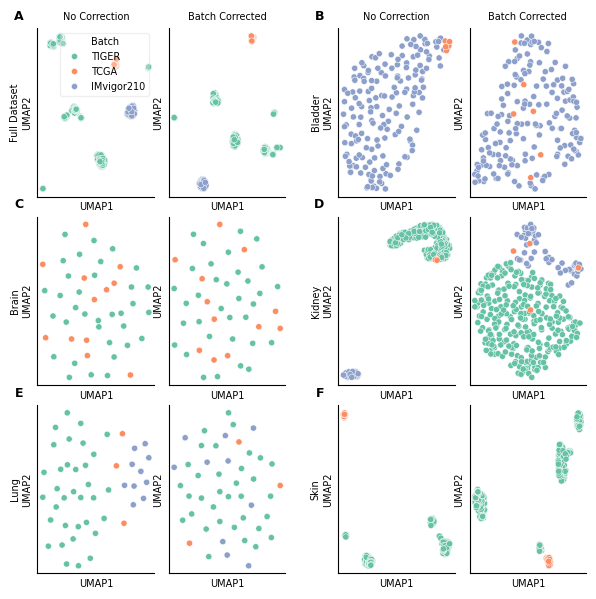

In [5]:
# =========================
# PLOTTING CELL
# =========================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import math

# --- Controls ---
s_size = 20
fs = 7

plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "legend.title_fontsize": fs,
})

batch_order = ['TIGER', 'TCGA', 'IMvigor210']
batch_palette = sns.color_palette("Set2", n_colors=len(batch_order))
batch_colors = dict(zip(batch_order, batch_palette))

# --- Layout ---
files = list(results.keys())
n_tissues = len(files)
n_rows = math.ceil(n_tissues / 2)

fig = plt.figure(figsize=(7.08, 7.08))

gs = gridspec.GridSpec(
    n_rows,
    5,
    width_ratios=[1, 1, 0.2, 1, 1],
    hspace=0.12,
    wspace=0.15
)

axes = []
for r in range(n_rows):
    axes.append([
        fig.add_subplot(gs[r, 0]),
        fig.add_subplot(gs[r, 1]),
        fig.add_subplot(gs[r, 3]),
        fig.add_subplot(gs[r, 4])
    ])
axes = np.array(axes)

panel_labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

# --- Plot ---
for idx, file in enumerate(files):

    row = idx // 2
    col_offset = (idx % 2) * 2

    df_u = results[file]["unprocessed"].copy()
    df_p = results[file]["processed"].copy()

    # categorical order
    for df in (df_u, df_p):
        df['batch'] = pd.Categorical(df['batch'], categories=batch_order, ordered=True)

    tissue_name = file.replace('.csv','').replace('_',' ').title()

    # --- Unprocessed ---
    sns.scatterplot(
        data=df_u,
        x='UMAP1', y='UMAP2',
        hue='batch',
        palette=batch_colors,
        s=s_size,
        ax=axes[row, col_offset],
        legend=(idx == 0)
    )

    # --- Processed ---
    sns.scatterplot(
        data=df_p,
        x='UMAP1', y='UMAP2',
        hue='batch',
        palette=batch_colors,
        s=s_size,
        ax=axes[row, col_offset+1],
        legend=False
    )

    # Labels
    axes[row, col_offset].text(
        -0.15, 0.5, tissue_name,
        rotation=90, va='center', ha='right',
        transform=axes[row, col_offset].transAxes,
        fontsize=fs
    )

    # panel letter
    axes[row, col_offset].text(
        -0.12, 1.05, panel_labels[idx],
        transform=axes[row, col_offset].transAxes,
        fontsize=fs+2, fontweight='bold',
        ha='right'
    )

# Titles
titles = ["No Correction","Batch Corrected","No Correction","Batch Corrected"]
for i in range(4):
    axes[0,i].set_title(titles[i], fontsize=fs)

# Style
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.spines[['right','top']].set_visible(False)

# Legend
axes[0,0].legend(title="Batch", fontsize=fs, title_fontsize=fs, framealpha=0.3)

#Save
name = 'S7'
figures_dir = '/home/lnemati/pathway_crosstalk/results/figures/new_figures'
os.makedirs(os.path.join(figures_dir, name), exist_ok=True)

plt.savefig(os.path.join(figures_dir, name, name) + '.pdf', bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(figures_dir, name, name) + '.png', bbox_inches='tight', dpi=300)

plt.show()